# 1.Vector and Matrix Norm

In [12]:
from numpy import linalg as LA
v = [-1,2,7,5]
LA.norm(v)
LA.norm(v,1)
LA.norm(v,np.inf)

7.0

# 2. KL-Divergence

In [13]:
import numpy as np
from numpy import linalg as LA
v1 = np.array([1,0,0,0,1,0,0,0,1,0,0])
v2 = np.array([1,0,0,0,1,0,0,0,1,0,0])
v3 = np.array([0,1,1,1,1,1,1,1,1,0,0])
v4 = np.array([1,0,2,0,2,0,1,2,1,1,0])
print([LA.norm(v1-v2), LA.norm(v1-v3),LA.norm(v1-v4),LA.norm(v2-v3), LA.norm(v2-v4), LA.norm(v3-v4)])
v1n = v1/LA.norm(v1)
v2n = v2/LA.norm(v2)
v3n = v3/LA.norm(v3)
v4n = v4/LA.norm(v4)

print([1-(v1n @ v2n), 1-(v1n @ v3n), 1-(v1n @ v4n), 1-(v2n @ v3n), 1-(v2n @ v4n), 1-(v3n @ v4n)])

[0.0, 2.6457513110645907, 3.3166247903554, 2.6457513110645907, 3.3166247903554, 2.8284271247461903]
[-2.220446049250313e-16, 0.591751709536137, 0.42264973081037416, 0.591751709536137, 0.42264973081037416, 0.29289321881345254]


# 3.Linear Regression

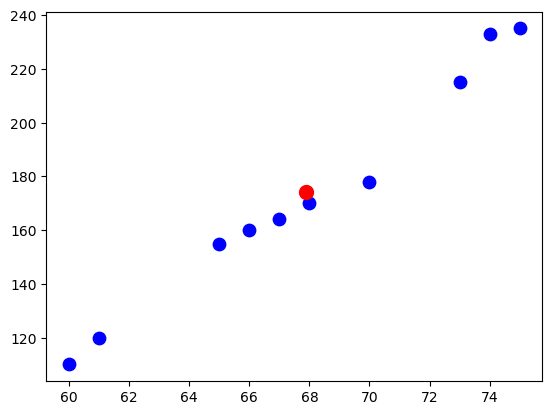

8.21502698215027 -383.8003320880034
8.215026982150269 -383.80033208800296
183.03652968036556


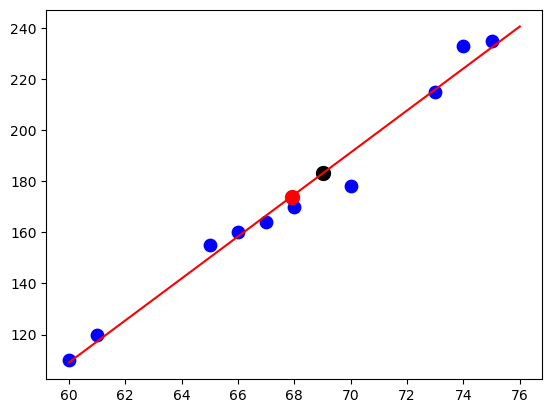

In [14]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
# %matplotlib inline # use this line in notebooks
x = np.array([66, 68, 60, 70, 65, 61, 74, 73, 75, 67])
y = np.array([160, 170, 110, 178, 155, 120, 233, 215, 235, 164])
ave_x = np.average(x)
ave_y = np.average(y)
plt.scatter(x,y, s=80, c="blue")
plt.scatter(ave_x ,ave_y , s=100, c="red")
plt.show()
xc = x - ave_x
yc = y - ave_y
a = xc.dot(yc)/xc.dot(xc)
b = ave_y - a*ave_x
print(a,b)

(a,b)=np.polyfit(x,y,1)
print(a,b)
w = a*69 + b
print(w)
h=np.linspace(60,76,17)
line=a*h+b
plt.scatter(x,y, s=80, c="blue")
plt.scatter(67.9,174, s=100, c="red")
plt.scatter(69,a*69+b, s=100, c="black")
plt.plot(h,line ,"r-")
plt.show()

# 4.Cross-Validation

[-0.35204082  0.72142857  1.44795918]
2.7409777176176284


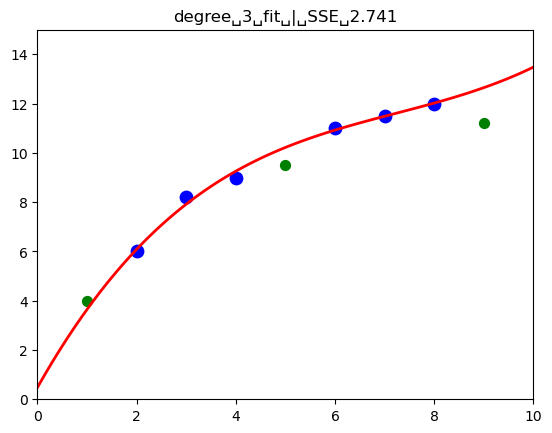

In [20]:
xT = np.array([2, 3, 4, 6, 7, 8])
yT = np.array([6, 8.2, 9, 11, 11.5, 12])
xE = np.array([1, 5, 9])
yE = np.array([4, 9.5, 11.2])

p=3
coefs=np.polyfit(xT,yT,p)
M = np.poly1d(coefs)
resid = M(xE) - yE
print(resid)
SSE = LA.norm(resid)**2
print(SSE)

plt.axis([0,10,0,15])
s=np.linspace(0,10,101)
plt.plot(s,M(s),'r-',linewidth=2.0)
plt.scatter(xT,yT, s=80, c="blue")
plt.scatter(xE,yE, s=50, c="green")
plt.title("degree␣%s␣fit␣|␣SSE␣%0.3f"% (p, SSE))
plt.show()

# 5.Matching Pursuit with n < d

In [6]:
X = np.array([[1, 8, -3, 5, 4, -9, 4],[1,-2,4,8,-2,-3,2],
[1,9,6,-7,4,-5,-5],[1,6,-14,-5,-3,9,-2],
[1,-2,11,-6,3,-5,1]])
a = np.array([0,0,0,5,0,-2,0])
noise = np.random.normal(0,0.5,5)
y = X@a + noise
s = 0.5 # regularization parameter
k = 3 # number of iterations
print("norm:␣", LA.norm(y), y)
r = y
for i in range(k):
# select column index most aligned with residual
    j = np.argmax(abs(r@X))
# find best model parameter at j to fit residual
    ajp = (np.dot(r,X[:,j])+s/2) / (LA.norm(X[:,j])**2)
    ajm = (np.dot(r,X[:,j])-s/2) / (LA.norm(X[:,j])**2)
    if (LA.norm(r-X[:,j]*ajp) + s*abs(ajp) <
    LA.norm(r-X[:,j]*ajm) + s*abs(ajm)):
        aj = ajp
    else:
        aj = ajm
# udpate residual
r = r - X[:,j]*aj
print("update:␣", j, aj, LA.norm(r))
# Ordinary Least Squares
print("OLS:␣", LA.inv(X.T@X) @ X.T@y.T)
# Ridge Regression
print("ridge:␣", LA.inv(X.T@X + s*np.identity(7)) @ X.T@y.T)

norm:␣ 81.89632611463838 [ 42.53626739  44.9802471  -24.96428331 -42.97117629 -20.11750796]
update:␣ 3 5.44012173886849 28.546421632099023
OLS:␣ [-91.60545557   7.40394294   1.34847712   6.1605378   -6.09864876
  -8.65619885   4.04361028]
ridge:␣ [-0.54817969  0.12160076  0.07565856  4.91952678 -0.01041035 -1.88658326
  0.19258865]


# 6.Gradient descent

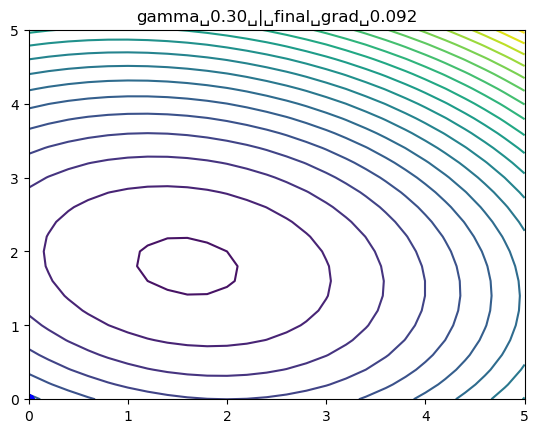

In [7]:
import numpy as np
from numpy import linalg as LA
import matplotlib.pyplot as plt
%matplotlib inline
def func(x,y):
    return (0.75*x-1.5)**2 + (y-2.0)**2 + 0.25*x*y
def func_grad(vx,vy):
    dfdx = 1.125*vx - 2.25 + 0.25*vy
    dfdy = 2.0*vy - 4.0 + 0.25*vx
    return np.array([dfdx,dfdy])
xlist = np.linspace(0,5,26)
ylist = np.linspace(0,5,26)
x,y = np.meshgrid(xlist,ylist)
z = func(x,y)
lev = np.linspace(0,20,21)

v_init = np.array([5,4])
num_iter = 10
values = np.zeros([num_iter ,2])
values[0,:] = v_init
v = v_init
gamma = 0.3

values = np.zeros([num_iter ,2])
plt.contour(x,y,z,levels=lev)
plt.plot(values[:,0],values[:,1],'r-')
plt.plot(values[:,0],values[:,1],'bo')
for i in range(1,num_iter):
    v = v - gamma * func_grad(v[0],v[1])
    values[i,:] = v
grad_norm = LA.norm(func_grad(v[0],v[1]))
title = "gamma␣%0.2f␣|␣final␣grad␣%0.3f" % (gamma ,grad_norm)
plt.title(title)
plt.show()


# 7.Tracing through the SVD

In [8]:
import numpy as np
from scipy import linalg as LA
A = np.array([[4.0,3.0], [2.0,2.0], [-1.0,-3.0], [-5.0,-2.0]])
U, s, Vt = LA.svd(A)
print(U)
print(s)
print(Vt)
x = np.array([0.243,0.97])
x = x/LA.norm(x)
p = Vt @ x
print(p)
S = LA.diagsvd(s,4,2)
q = S @ p
print(q)
y = U @ q
print(y)
print(A @ x)

[[-0.61215255 -0.05228813  0.06420835  0.78639208]
 [-0.34162337 -0.2025832   0.84891247 -0.34871356]
 [ 0.31300005  0.80704816  0.42637948  0.26249717]
 [ 0.64077586 -0.55217683  0.30565577  0.4371288 ]]
[8.16552039 2.30743942]
[[-0.81424526 -0.58052102]
 [ 0.58052102 -0.81424526]]
[-0.7609864  -0.64876784]
[-6.21384993 -1.49699248  0.          0.        ]
[ 3.88209899  2.42606187 -3.1530804  -3.15508046]
[ 3.88209899  2.42606187 -3.1530804  -3.15508046]


# 8.Classical Multidimensional Scaling

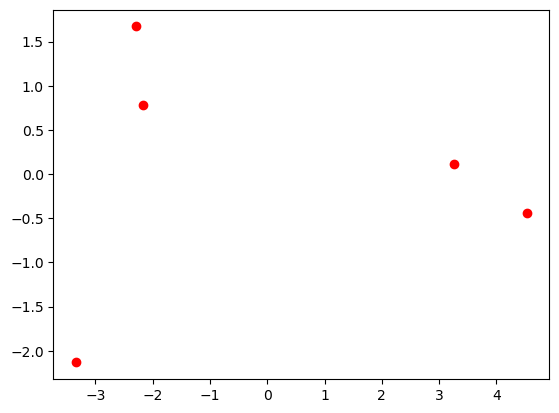

In [9]:
D = np.array([[0,4,3,7,8],[4,0,1,6,7],[3,1,0,5,7],[7,6,5,0,1],

[8,7,7,1,0]])

D2 = np.square(D)
C = np.eye(5) - 0.2*np.ones(5)
M = -0.5* C @ D2 @ C
l,V = LA.eig(M)
s = np.real(np.power(l,0.5))
V2 = V[:,[0,1]]
s2 = np.diag(s[0:2])
Q = V2 @ s2
import matplotlib.pyplot as plt
plt.plot(Q[:,0],Q[:,1],"ro")
plt.show()

# 9.Normal Distribution

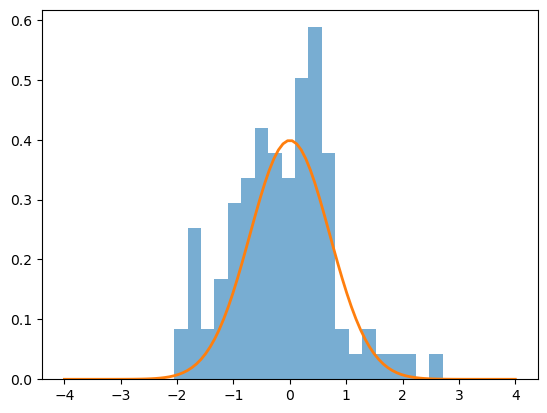

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linspace 
data=np.random.normal(0,1,100)
x=np.linspace(-4,4,100)
y=(1/(np.sqrt(2*np.pi)))*np.exp(-x**2)
plt.hist(data,bins=20,density=True,alpha=0.6)

plt.plot(x,y,linewidth=2)
plt.show()

# 10.Scatter plots

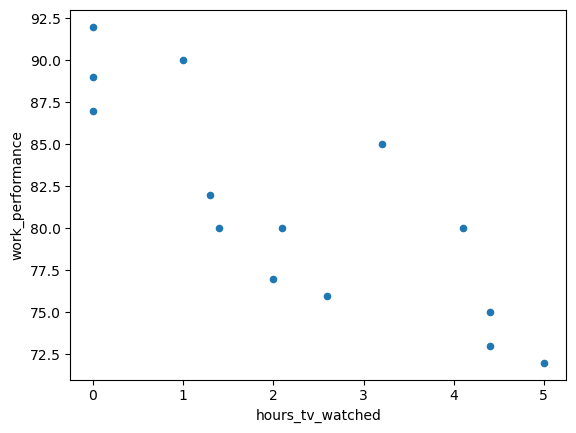

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
hours_tv_watched = [0,0,0,1,1.3,1.4,2,2.1,2.6,3.2,4.1,4.4,4.4,5]
work_performance = [87,89,92,90,82,80,77,80,76,85,80,75,73,72]
df = pd.DataFrame({'hours_tv_watched':hours_tv_watched,'work_performance':work_performance})
df.plot(x='hours_tv_watched',y="work_performance", kind="scatter")
plt.show()